# PW1 - Handwritten character recognition


In [1]:
# Write your name here (e.g. "Edmond Dantès") so I can grade your work
your_name = "Quentin Marret"
assert your_name

In [2]:
%matplotlib inline
import math, sys, os, torch, torchvision
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Using gpu: %s ' % torch.cuda.is_available())

Using gpu: False 


We will be training many models. Select a number of epochs to train each model. If you are using a slow machine, or if you want to restart training often and have many development iterations, we suggest `NUM_EPOCH = 2`. If you are using a fast machine, or have a GPU available, of if you are confident that you can write accurate code first try, you will get better accuracies by increasing this constant. You could be able to afford up to `NUM_EPOCH = 10`.

In [4]:
NUM_EPOCH = 2

# Part A - Linear, MLP, and CNN


## Handwritten digit recognition dataset

We will use the MNIST database (Modified National Institute of Standards and Technology database). It contains tens of thousands of pictures of handwritten digits. This database was compiled in 1994, as part of the effort in the 1990s to standardize automation of sorting devices with human input, for instance sorting mail with handwritten postal codes at the post office. This is now often considered one of the first real successes of neural networks, and the first easy example on which performance of new such algorithms is tested.

Load the dataset (train and test splits) using `torchvision`

In [5]:
root_dir = './data/MNIST/'

### YOUR CODE HERE ###
import torchvision.transforms as transforms

# transformer les images en tenseurs [1×28×28]
transform = transforms.ToTensor()

### YOUR CODE HERE ###
# Download the MNIST dataset
trainset = torchvision.datasets.MNIST(root=root_dir, train=True, download=True, transform=transform)
valset = torchvision.datasets.MNIST(root=root_dir, train=False, download=True, transform=transform)

# Load the dataset using DataLoader of torchvision
trainloader = torch.utils.data.DataLoader(trainset, shuffle=True, batch_size=256)
testloader = torch.utils.data.DataLoader(valset, shuffle=True, batch_size=256)

In [6]:
for batch_idx, (inputs, targets) in enumerate(testloader):
    # inputs : tenseur de forme (batch_size, C, H, W)
    # targets: tenseur des labels de forme (batch_size,)
    img0 = inputs[0]       # tenseur (C, H, W)
    label0 = targets[0]    # entier
    print(f"Batch {batch_idx} — inputs {inputs.shape}, targets {targets.shape} - 1ère image {img0.shape}, 1er label {label0}")
    if batch_idx > 2:
        break

Batch 0 — inputs torch.Size([256, 1, 28, 28]), targets torch.Size([256]) - 1ère image torch.Size([1, 28, 28]), 1er label 3
Batch 1 — inputs torch.Size([256, 1, 28, 28]), targets torch.Size([256]) - 1ère image torch.Size([1, 28, 28]), 1er label 6
Batch 2 — inputs torch.Size([256, 1, 28, 28]), targets torch.Size([256]) - 1ère image torch.Size([1, 28, 28]), 1er label 9
Batch 3 — inputs torch.Size([256, 1, 28, 28]), targets torch.Size([256]) - 1ère image torch.Size([1, 28, 28]), 1er label 1


How many examples in each split? 

Plot the first image and label of the training set using `matplotlib`

What is the input dimension?

In [7]:
### YOUR CODE HERE ###
print("Dimensions data test: ", trainloader.dataset.data.shape)

print("\nDimensions data test: ", testloader.dataset.data.shape)

print("\nNombre de batch de 256 images dans le trainloader : ", len(trainloader))

Dimensions data test:  torch.Size([60000, 28, 28])

Dimensions data test:  torch.Size([10000, 28, 28])

Nombre de batch de 256 images dans le trainloader :  235


___
> * Il y a **60 000 exemples** de dimensions ```28x28``` dans le split ```train``` 

> * Et il y a **10 000 exemples** de dimensions ```28x28``` dans le split ```test```
___

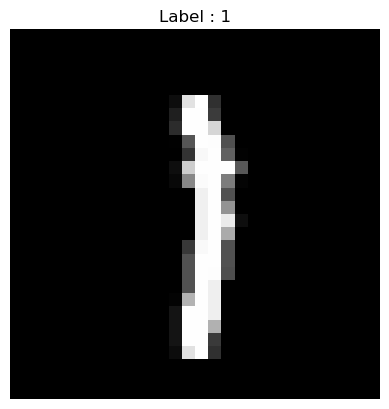

In [8]:
# Affichage d'une image et de son label avec matplotlib
inputs, targets = next(iter(trainloader))     
image = inputs[0, 0]# # 1ère image du batch                          

plt.imshow(image, cmap='gray')
plt.title(f'Label : {targets[0].item()}')
plt.axis('off')
plt.show()

# A.1 - Linear features

We start with a very simple model, linear with respect to pixel values.
Use a `preprocess` function to downsample the image to 7x7 pixels, then flatten it and use a `torch.nn.Linear` model.

The torch average-pooling function is `torch.nn.functional.avg_pool2d`, check the documentation to set the arguments properly.
DO NOT use your implementation of average-pooling, it would take prohibitively long to train and you would not finish the practical.
If the training takes too long, go back to the first section and lower the `NUM_EPOCH` constant.

Again, use matplotlib to visualize an example of downsampling

image.shape torch.Size([1, 28, 28])
downsampled.shape torch.Size([1, 7, 7])


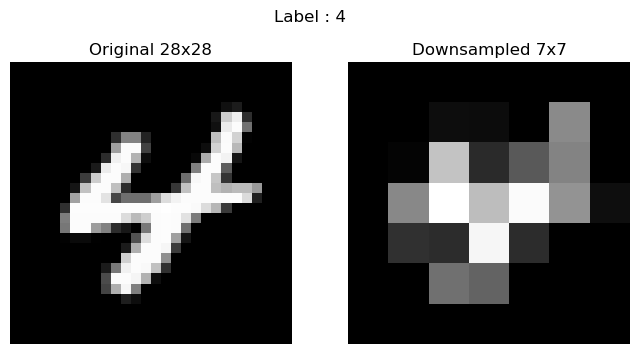

In [9]:
import torch.nn as nn
import torch.nn.functional as F

# Prendre une image de la base de données
inputs, targets = next(iter(trainloader))
image = inputs [0]  # --> (1, 28, 28)
print("image.shape", image.shape)  # --> (1, 1, 28, 28)


downsampled = F.avg_pool2d(image, kernel_size=4, stride=4) # size (1, 7, 7) 
print("downsampled.shape",downsampled.shape)

# Afficher les 2 images
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(image.squeeze(0), cmap='gray')
axs[0].axis('off')
axs[0].set_title("Original 28x28")

axs[1].imshow(downsampled.squeeze(0), cmap='gray')
axs[1].axis('off')
axs[1].set_title("Downsampled 7x7")

# Afficher le label
fig.suptitle(f'Label : {targets[0].item()}')

# Afficher le graph
plt.axis('off')
plt.show()

In [10]:
flatten = nn.Flatten() # Utilisé pour transformer une image 2D en un vecteur 1D

def preprocess(x):
    # avg‑pool 28×28 → 7×7
    x = F.avg_pool2d(x, kernel_size=4, stride=4)       
    # aplatissement via le module nn.Flatten
    x_flat = flatten(x) # transforme l'image 7x7 en un vecteur 1D de taille 49                          
    return x_flat 

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1*49, 10)  # 7x7 = 49, num_classes = 10

    def forward(self, x):
        # x: (B, 1, 28, 28)   # on flatten les images
        logits = self.fc(x)   # on récupère les prédictions pour chacune des 10 classes
        return logits

In [11]:
# Prendre une image de la base de données
inputs, targets = next(iter(trainloader))
image = inputs 
print("image.shape", image.shape)  # --> (1, 1, 28, 28)

processed_image = preprocess(image)  # --> (1, 49)
print("processed_image.shape", processed_image.shape)  # --> (64, 49) 64 "images" 1D de 49 pixels

image.shape torch.Size([256, 1, 28, 28])
processed_image.shape torch.Size([256, 49])


## A.2 - Loss and optimizer
Create a cross entropy loss.

In [12]:
criterion = nn.CrossEntropyLoss()

## A.3 - Training and testing loops
Finally, create the functions `train(model, epoch, preprocess, optimizer)` and `test(model)` to train (one epoch with SGD and a learning rate of $10^{-3}$) and test your model.

In [13]:
def train(model, epoch, preprocess, optimizer, verbose=True):
    model.to(device)
    model = model.train()
    total_loss, total_correct, total_samples = 0., 0, 0
    num_batches = 0
    
    for inputs, targets in trainloader: # on itère sur les batches de taille 256
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        processed_inputs = preprocess(inputs)  # <-- AVG_pooling + flatten avant d'envoyer dans le modèle
        outputs = model(processed_inputs)              
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        batch_size = inputs.size(0)
        total_loss+= loss.item() * batch_size
        total_correct+= (outputs.argmax(1)==targets).sum().item()
        total_samples+= batch_size
        num_batches+= 1
        if (verbose==True) and (num_batches % 47 == 0): # car il y a 235 donc 5 x 47 batchs par epoch
            print(f"Epoch {epoch} - N° Batch {num_batches} - Loss: {loss.item():.4f} - Batch accuracy: {(outputs.argmax(1)==targets).sum().item()/batch_size:.4f}")

    accuracy = total_correct/total_samples
    return optimizer, accuracy

def test(model, preprocess = preprocess):
    model.eval()
    total_correct, total_samples = 0, 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            inputs = preprocess(inputs)  # <-- pooling+flatten avant d'envoyer dans le modèle
            outputs = model(inputs)    
            total_correct+= (outputs.argmax(1)==targets).sum().item()
            total_samples+= inputs.size(0)

    acc = total_correct/total_samples
    return acc

In [14]:
model_Linear = LinearModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_Linear = torch.optim.SGD(model_Linear.parameters(), lr=10e-1) #Je choisi un learning rate de 1 (VS 0.01 conseillé) car j'ai remarqué que c'était le plus efficace pour ce modèle.

# Entraînement du modèle sur une seule epoch
optimizer, accuracy = train(model_Linear, epoch=1, preprocess=preprocess, optimizer=optimizer_Linear, verbose=True)
print(f"Train accuracy après 1 epoch: {accuracy:.4f}")

# Évaluation sur l'ensemble de test
test_acc = test(model_Linear, preprocess=preprocess)
print(f"Test  accuracy: {test_acc:.4f}\n")

Epoch 1 - N° Batch 47 - Loss: 1.2769 - Batch accuracy: 0.7500
Epoch 1 - N° Batch 94 - Loss: 0.9879 - Batch accuracy: 0.7891
Epoch 1 - N° Batch 141 - Loss: 0.7422 - Batch accuracy: 0.8516
Epoch 1 - N° Batch 188 - Loss: 0.7407 - Batch accuracy: 0.8438
Epoch 1 - N° Batch 235 - Loss: 0.7344 - Batch accuracy: 0.7812
Train accuracy après 1 epoch: 0.7797
Test  accuracy: 0.8428



In [15]:
NUM_EPOCH = 2

for epoch in range(1, NUM_EPOCH + 1):
    # Entraînement du modèle
    optimizer, train_acc = train(model_Linear, epoch=epoch, preprocess=preprocess, optimizer=optimizer_Linear)
    print(f"[Epoch {epoch}] Train accuracy: {train_acc:.4f}")
    
    # Évaluation sur l'ensemble de test
    test_acc = test(model_Linear, preprocess=preprocess)
    print(f"[Epoch {epoch}] Test  accuracy: {test_acc:.4f}\n")

Epoch 1 - N° Batch 47 - Loss: 0.7073 - Batch accuracy: 0.8242
Epoch 1 - N° Batch 94 - Loss: 0.6643 - Batch accuracy: 0.8281
Epoch 1 - N° Batch 141 - Loss: 0.6488 - Batch accuracy: 0.8320
Epoch 1 - N° Batch 188 - Loss: 0.5596 - Batch accuracy: 0.8750
Epoch 1 - N° Batch 235 - Loss: 0.5268 - Batch accuracy: 0.8542
[Epoch 1] Train accuracy: 0.8430
[Epoch 1] Test  accuracy: 0.8591

Epoch 2 - N° Batch 47 - Loss: 0.6082 - Batch accuracy: 0.8555
Epoch 2 - N° Batch 94 - Loss: 0.5625 - Batch accuracy: 0.8555
Epoch 2 - N° Batch 141 - Loss: 0.5559 - Batch accuracy: 0.8281
Epoch 2 - N° Batch 188 - Loss: 0.5951 - Batch accuracy: 0.8203
Epoch 2 - N° Batch 235 - Loss: 0.5830 - Batch accuracy: 0.8125
[Epoch 2] Train accuracy: 0.8534
[Epoch 2] Test  accuracy: 0.8668



You should get at least 85\% test accuracy even with only 2 epochs. We will be aiming for around 95\% test accuracy and above.

> Avec 2 épochs, j'atteins bien un ```test accuracy``` supérieur à 85\%

## A.4 - Multi-layer perceptron (MLP)

Create a class MLP that creates an MLP of given width and depth, and use it to create a 3-layer MLP of width $100$. We will assume that `width > 0` and `depth > 0`.

In [16]:
class MLP(nn.Module):
    def __init__(self, input_dim=49, width=100, depth=3, output_dim=10):
        
        # On vérifie que les dimensions sont valides
        assert not depth < 2, "Le réseau doit avoir au moins 2 couches"
        assert not width < 1, "La largeur doit être supérieure à 0"

        super().__init__()
        layers = []

        # Couche d'entrée + activation
        layers.append(nn.Linear(input_dim, width))
        layers.append(nn.ReLU())

        # Couches cachées
        # On fait depth−2 itérations pour obtenir, en tout : [1 couche entrée] + [depth−2 couches cachées] + [1 couche sortie] = depth couches
        for layer in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())

        # Couche de sortie (sans activation)
        layers.append(nn.Linear(width, output_dim))
        self.model = nn.Sequential(*layers) # nn.Sequential permet de créer un modèle séquentiel en empilant les couches du modèle

    def forward(self, x):
        # applique successivement chaque module de self.model à x en appelant selement la fonction nn.Sequential
        return self.model(x)

In [17]:
model_MLP= MLP(input_dim=49, width=100, depth=3, output_dim=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_MLP = torch.optim.SGD(model_MLP.parameters(), lr=10e-1) #Je garde le learning rate de 1 (VS 0.01 conseillé) car j'ai remarqué que c'était le plus efficace pour ce modèle.
print("Architecture du 3-Layers MPL :\n", model_MLP)

Architecture du 3-Layers MPL :
 MLP(
  (model): Sequential(
    (0): Linear(in_features=49, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)


In [18]:
#NUM_EPOCH = 4

for epoch in range(1, NUM_EPOCH + 1):
    # Entraînement de l'époque `epoch`
    optimizer, train_acc = train(model_MLP, epoch=epoch, preprocess=preprocess, optimizer=optimizer_MLP)
    print(f"[Epoch {epoch}] Train accuracy: {train_acc:.4f}")
    
    # Évaluation sur l'ensemble de test
    test_acc = test(model_MLP)
    print(f"[Epoch {epoch}] Test  accuracy: {test_acc:.4f}\n")

Epoch 1 - N° Batch 47 - Loss: 1.0195 - Batch accuracy: 0.6562
Epoch 1 - N° Batch 94 - Loss: 0.9275 - Batch accuracy: 0.7305
Epoch 1 - N° Batch 141 - Loss: 0.3414 - Batch accuracy: 0.8555
Epoch 1 - N° Batch 188 - Loss: 0.3582 - Batch accuracy: 0.8633
Epoch 1 - N° Batch 235 - Loss: 0.4260 - Batch accuracy: 0.8646
[Epoch 1] Train accuracy: 0.7125
[Epoch 1] Test  accuracy: 0.8590

Epoch 2 - N° Batch 47 - Loss: 0.4090 - Batch accuracy: 0.8594
Epoch 2 - N° Batch 94 - Loss: 0.4363 - Batch accuracy: 0.8477
Epoch 2 - N° Batch 141 - Loss: 0.3044 - Batch accuracy: 0.9062
Epoch 2 - N° Batch 188 - Loss: 0.2476 - Batch accuracy: 0.9141
Epoch 2 - N° Batch 235 - Loss: 0.3764 - Batch accuracy: 0.8750
[Epoch 2] Train accuracy: 0.9039
[Epoch 2] Test  accuracy: 0.8623



> J'obtiens un ```test accuracy``` proche de **96%** avec 10 epochs

# A.5 - Deep convolutional model

Write a convolutional model, with learned features.
Use two layers, one convolutional with 8 filters of size 3x3, then take a relu and max-pool with kernel size 2, and finally flatten and add a Linear layer. You can use the identity as pre-processing function.


Here is a little animation to remind you of the sliding window principle of convolutions.

![conv](https://github.com//vdumoulin/conv_arithmetic/raw/master/gif/no_padding_no_strides.gif)

In [19]:
import torch.nn.functional as F
class ConvModel(torch.nn.Module):
    def __init__(self):
        super(ConvModel, self).__init__()
        ### YOUR CODE HERE ###
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)
        self.pool  = nn.MaxPool2d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.fc    = nn.Linear(8 * 13 * 13, 10)

    def forward(self,x):
        x = F.relu(self.conv1(x))  # --> (B, 8, 26, 26)
        x = self.pool(x)           # --> (B, 8, 13, 13) car maxPool2d(2) réduit la taille de moitié (il prend un pixel par carré de 2x2)
        x = self.flatten(x)        # --> (B, 8*13*13)
        logits = self.fc(x)        # --> (B, 10)
        return logits

In [20]:
model_CNN= ConvModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_CNN = torch.optim.SGD(model_CNN.parameters(), lr=1e-1) #Je prends un learning rate de 0.1 (VS 10e-3 conseillé) car j'ai remarqué que c'était le plus efficace pour ce modèle.
print(model_CNN)

ConvModel(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=1352, out_features=10, bias=True)
)


In [21]:
NUM_EPOCH = 10

for epoch in range(1, NUM_EPOCH + 1):
    # Entraînement de l'époque `epoch`
    optimizer, train_acc = train(model_CNN, epoch=epoch, preprocess=lambda x:x, optimizer=optimizer_CNN)
    print(f"[Epoch {epoch}] Train accuracy: {train_acc:.4f}")
    
    # Évaluation sur l'ensemble de test
    test_acc = test(model_CNN,  preprocess=lambda x:x)
    print(f"[Epoch {epoch}] Test  accuracy: {test_acc:.4f}\n")

Epoch 1 - N° Batch 47 - Loss: 0.4967 - Batch accuracy: 0.8477
Epoch 1 - N° Batch 94 - Loss: 0.4326 - Batch accuracy: 0.8633
Epoch 1 - N° Batch 141 - Loss: 0.4943 - Batch accuracy: 0.8516
Epoch 1 - N° Batch 188 - Loss: 0.3270 - Batch accuracy: 0.9141
Epoch 1 - N° Batch 235 - Loss: 0.3281 - Batch accuracy: 0.9167
[Epoch 1] Train accuracy: 0.8382
[Epoch 1] Test  accuracy: 0.9027

Epoch 2 - N° Batch 47 - Loss: 0.2855 - Batch accuracy: 0.9219
Epoch 2 - N° Batch 94 - Loss: 0.2431 - Batch accuracy: 0.9375
Epoch 2 - N° Batch 141 - Loss: 0.3044 - Batch accuracy: 0.9102
Epoch 2 - N° Batch 188 - Loss: 0.3248 - Batch accuracy: 0.9023
Epoch 2 - N° Batch 235 - Loss: 0.3027 - Batch accuracy: 0.9062
[Epoch 2] Train accuracy: 0.9050
[Epoch 2] Test  accuracy: 0.9109

Epoch 3 - N° Batch 47 - Loss: 0.2240 - Batch accuracy: 0.9180
Epoch 3 - N° Batch 94 - Loss: 0.3508 - Batch accuracy: 0.8984
Epoch 3 - N° Batch 141 - Loss: 0.1958 - Batch accuracy: 0.9453
Epoch 3 - N° Batch 188 - Loss: 0.2334 - Batch accurac

You should be able to get around 97\% to 98\% accuracy with this model. Try increasing the NUM_EPOCH constant and watch what happens to test accuracy and train accuracy as training progresses further.

> J'obtiens un test accuracy **> 97\%** au bout de 10 epochs

Write a deeper convolutional model, with one convolutional layer as previously, but three linear layers with relu activations after that.
Use `h = 100` hidden neurons. How does the test accuracy compare with the previous two-layer network ?

In [22]:
class ConvDeepModel(torch.nn.Module):
    def __init__(self, hidden_neurons=100):
        super(ConvDeepModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)
        self.pool  = nn.MaxPool2d(kernel_size=2)
        self.flatten = nn.Flatten()
        
        # three FC layers
        self.fc1 = nn.Linear(8 * 13 * 13, hidden_neurons)
        self.fc2 = nn.Linear(hidden_neurons, hidden_neurons)
        self.fc3 = nn.Linear(hidden_neurons, 10)


    def forward(self,x):
        x = F.relu(self.conv1(x))  # --> (B, 8, 26, 26)
        x = self.pool(x)           # --> (B, 8, 13, 13)
        x = self.flatten(x)        # --> (B, 8*13*13)
        x = F.relu(self.fc1(x))    # --> (B,h)
        x = F.relu(self.fc2(x))    # --> (B,h)
        logits = self.fc3(x)       # --> (B, 10)
        return logits

In [23]:
Deep_CNN= ConvDeepModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_Deep_CNN = torch.optim.SGD(Deep_CNN.parameters(), lr=1e-1) #Je garde un learning rate de 0.1 (VS 10e-3 conseillé) car j'ai remarqué que c'était le plus efficace pour ce modèle.
print(Deep_CNN)

ConvDeepModel(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1352, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [24]:
NUM_EPOCH = 10

for epoch in range(1, NUM_EPOCH + 1):
    # Entraînement de l'époque `epoch`
    optimizer, train_acc = train(Deep_CNN, epoch=epoch, preprocess=lambda x:x, optimizer=optimizer_Deep_CNN)
    print(f"[Epoch {epoch}] Train accuracy: {train_acc:.4f}")
    
    # Évaluation sur l'ensemble de test
    test_acc_Deep_CNN = test(Deep_CNN,  preprocess=lambda x:x)
    print(f"[Epoch {epoch}] Test  accuracy: {test_acc_Deep_CNN:.4f}\n")

Epoch 1 - N° Batch 47 - Loss: 2.1715 - Batch accuracy: 0.6172
Epoch 1 - N° Batch 94 - Loss: 0.8938 - Batch accuracy: 0.7266
Epoch 1 - N° Batch 141 - Loss: 0.5199 - Batch accuracy: 0.8281
Epoch 1 - N° Batch 188 - Loss: 0.4198 - Batch accuracy: 0.8438
Epoch 1 - N° Batch 235 - Loss: 0.2269 - Batch accuracy: 0.9583
[Epoch 1] Train accuracy: 0.6879
[Epoch 1] Test  accuracy: 0.8935

Epoch 2 - N° Batch 47 - Loss: 0.2958 - Batch accuracy: 0.9062
Epoch 2 - N° Batch 94 - Loss: 0.3261 - Batch accuracy: 0.9258
Epoch 2 - N° Batch 141 - Loss: 0.2593 - Batch accuracy: 0.9336
Epoch 2 - N° Batch 188 - Loss: 0.2433 - Batch accuracy: 0.9336
Epoch 2 - N° Batch 235 - Loss: 0.1951 - Batch accuracy: 0.9271
[Epoch 2] Train accuracy: 0.9192
[Epoch 2] Test  accuracy: 0.9311

Epoch 3 - N° Batch 47 - Loss: 0.1688 - Batch accuracy: 0.9492
Epoch 3 - N° Batch 94 - Loss: 0.1726 - Batch accuracy: 0.9414
Epoch 3 - N° Batch 141 - Loss: 0.1669 - Batch accuracy: 0.9375
Epoch 3 - N° Batch 188 - Loss: 0.1307 - Batch accurac

___
> On remarque qu'en ajoutant 2 couches linéaires très large (100 neurones), on augmente très peu notre ```test accuracy``` par rapport au modèle précédant (97\% vs 97,7\%) alors qu'on a ajouté plus de 100 000 paramètres supplémentaires au modèle.

> De plus, en augmentant le nombre de paramètre, ces 2 couches supplémentaires accroissent le risque d'**overfitting** sur le dataset d'entrainement et semble donc inutile voire néfaste pour l'amélioreration des performences du modèle.
___

## A.6 Visualisations of convolutions

After training your model, let's see what features it has learned!

Plot an image from the test set then plot all 8 feature maps extracted by the convolutional layer

In [25]:
def visualize_features(model, testloader):

    # Charger le modèle et le mettre en mode évaluation
    model.to(device)
    model.eval()  # désactive dropout, batchnorm, etc.

    # Récupérer un batch et la première image
    inputs, targets = next(iter(testloader))
    img   = inputs[0:1].to(device)    # shape (1, C, H, W)
    label = targets[0].item()

    # Passage dans la couche conv + ReLU
    with torch.no_grad():
        conv1 = model.conv1(img)      # shape (1, F, H', W')
        feats = F.relu(conv1)         # appliquer ReLU pour voir les activations effectives qui sont transmises aux couches suivantes

    # Préparation pour affichage
    img2d   = img.squeeze(0).squeeze(0)  # 28×28
    feats   = feats.squeeze(0)           # (8, 26, 26)
    n_feats = feats.shape[0]

    # Afficher
    fig, axes = plt.subplots(1, 9, figsize=(12,4))
    
    # Image d’entrée
    axes[0].imshow(img2d, cmap='gray', interpolation='nearest')
    axes[0].set_title(f'Input (label={label})')
    axes[0].axis('off')

    # Feature maps
    for i in range(n_feats):
        axes[i+1].imshow(feats[i], cmap='gray', interpolation='nearest')
        axes[i+1].set_title(f'FM {i}')
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()


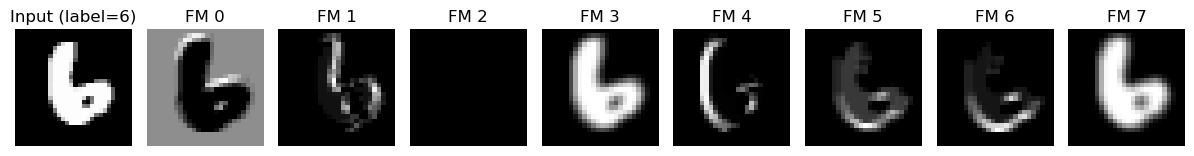

In [26]:
visualize_features(model=Deep_CNN, testloader=testloader)

# Part B - Residual models ** IN PROCESS**
**IN PROCESS**
## B.1 - Residual blocks

Write a residual block with two linear layers to learn a function $\mathbb{R}^d \to \mathbb{R}^d$ with $h < d$ hidden neurons.
Write a convolutional residual block with the same idea. What hyperparameter acts as the number of hidden neurons in convolutional blocks ?

In [27]:
class ResidualBlock(torch.nn.Module):
    def __init__(self, d, h):
        super(ResidualBlock, self).__init__()
        assert h < d, "hidden_channels must be smaller than out_channels"
        self.fc1 = nn.Linear(d, h)
        self.fc2 = nn.Linear(h, d)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.relu(self.fc1(x))  
        out = self.fc2(out)          
        return x + out    # skip connection            

In [28]:
class ResidualBlockConv(nn.Module):
    def __init__(self, in_out_channels: int, hidden_channels: int):
        super(ResidualBlockConv, self).__init__()
        assert hidden_channels < in_out_channels, "hidden_channels must be smaller than in_out_channels"
        self.conv1 = nn.Conv2d(in_out_channels,  hidden_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_channels, in_out_channels,  kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: (B, C, H, W)
        out = self.relu(self.conv1(x))  # --> (B, hidden_channels, H, W)
        out = self.conv2(out)           # --> (B, in_out_channels, H, W)
        return x + out  # skip connection. Retourne y = x + F(x), avec F(x) la fonction résiduelle.

___
> C'est la variable ```hidden_channels``` qui joue le rôle d'hyperparamètre concernant le nombre de neurones 
___

In [29]:
block = ResidualBlockConv(in_out_channels=8, hidden_channels=2)
x = torch.randn(32, 8, 28, 28)
out = block(x)
print(out.shape)

torch.Size([32, 8, 28, 28])


## B.2 - Stacking residual blocks

Use a ```single convolution layer```, followed by a ```relu``` and ```max-pool```, then an arbitrary number of ```residual blocks``` as defined above, and finish with a ```linear layer```. 
* Can you match the accuracy of the two-layer network ? 
* Can you exceed it ? What happens when you increase the number of layers ? 
* Look at the details of the ResNet architecture on the lecture's slides to get an idea of how to increase the number of hidden neurons and the number of layers. One of the strengths of ResNets was there relatively low number of parameters compared to a multi-layer architecture like that of the previous section, does this show in your experiments ?

**```REPONSES EN BAS```**

In [30]:
class ResidualModel(torch.nn.Module):
    def __init__(self, nb_ResBlock, hidden_channels, kernel_size=3, out=8):
        super(ResidualModel, self).__init__()
        assert hidden_channels < out, "hidden_channels must be smaller than out_channels" # pour garantir un effet bottleneck
        #Réseau conv → ReLU → max‑pool
        self.conv1 = nn.Conv2d(1, out, kernel_size=kernel_size, padding=kernel_size//2) #Padding obligatoire pour garder la même taille
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(kernel_size=2) # Réduit de moitié chaque dimension spatiale --> 28×28 --> 14×14.

        # stack nb_ResBlock residual blocks
        blocks = [ResidualBlockConv( in_out_channels = out, hidden_channels = hidden_channels) for _ in range(nb_ResBlock)]
        self.resblocks = nn.Sequential(*blocks)

        self.flatten = nn.Flatten()
        dim_flatten = out * 14 * 14 # 14 car on a fait un maxpooling de 2 sur une image de 28x28
        self.fc = nn.Linear(dim_flatten, 10) # 10 classes en sorties

    def forward(self, x):
        x = self.relu(self.conv1(x))   # --> (B, out, 28, 28)
        x = self.pool(x)               # --> (B, out, 14, 14)
        x = self.resblocks(x)          # --> still (B, out, 14, 14)
        x = self.flatten(x)            # --> (B, out*14*14)
        return self.fc(x)              # --> (B, 10)

In [31]:
NUM_EPOCH = 10
criterion = nn.CrossEntropyLoss()

results = {}      # key=(l,h) -> test_accuracy
params_dict = {}  # key=(l,h) -> nombre de paramètres

for l, h in [(1,2), (2,4), (3,6)]:
    ResNet = ResidualModel(nb_ResBlock=l, hidden_channels=h).to(device)
    opt   = torch.optim.SGD(ResNet.parameters(), lr=1e-1) #Je prends un learning rate de 0.1 (VS 10e-3 conseillé) car j'ai remarqué que c'était le plus efficace pour ce modèle.

    # Calcul du nombre de paramètres
    total_params = sum(p.numel() for p in ResNet.parameters() if p.requires_grad)
    params_dict[(l, h)] = total_params

    acc_list = []
    for epoch in range(1, NUM_EPOCH + 1):
        optimizer, accuracy = train(ResNet, epoch=epoch, preprocess=lambda x:x, optimizer=opt, verbose=False)
        acc = test(ResNet, preprocess=lambda x:x)
        acc_list.append(acc)
        print(f"Epoch {epoch:2d}, l={l}, h={h} → test_acc={acc:.4f}, params={total_params:,}")
    results[(l, h)] = acc_list
    print()

Epoch  1, l=1, h=2 → test_acc=0.9128, params=16,068
Epoch  2, l=1, h=2 → test_acc=0.9527, params=16,068
Epoch  3, l=1, h=2 → test_acc=0.9620, params=16,068
Epoch  4, l=1, h=2 → test_acc=0.9658, params=16,068
Epoch  5, l=1, h=2 → test_acc=0.9721, params=16,068
Epoch  6, l=1, h=2 → test_acc=0.9735, params=16,068
Epoch  7, l=1, h=2 → test_acc=0.9703, params=16,068
Epoch  8, l=1, h=2 → test_acc=0.9603, params=16,068
Epoch  9, l=1, h=2 → test_acc=0.9762, params=16,068
Epoch 10, l=1, h=2 → test_acc=0.9730, params=16,068

Epoch  1, l=2, h=4 → test_acc=0.9349, params=16,946
Epoch  2, l=2, h=4 → test_acc=0.9566, params=16,946
Epoch  3, l=2, h=4 → test_acc=0.9744, params=16,946
Epoch  4, l=2, h=4 → test_acc=0.9790, params=16,946
Epoch  5, l=2, h=4 → test_acc=0.9768, params=16,946
Epoch  6, l=2, h=4 → test_acc=0.9817, params=16,946
Epoch  7, l=2, h=4 → test_acc=0.9813, params=16,946
Epoch  8, l=2, h=4 → test_acc=0.9814, params=16,946
Epoch  9, l=2, h=4 → test_acc=0.9832, params=16,946
Epoch 10, l

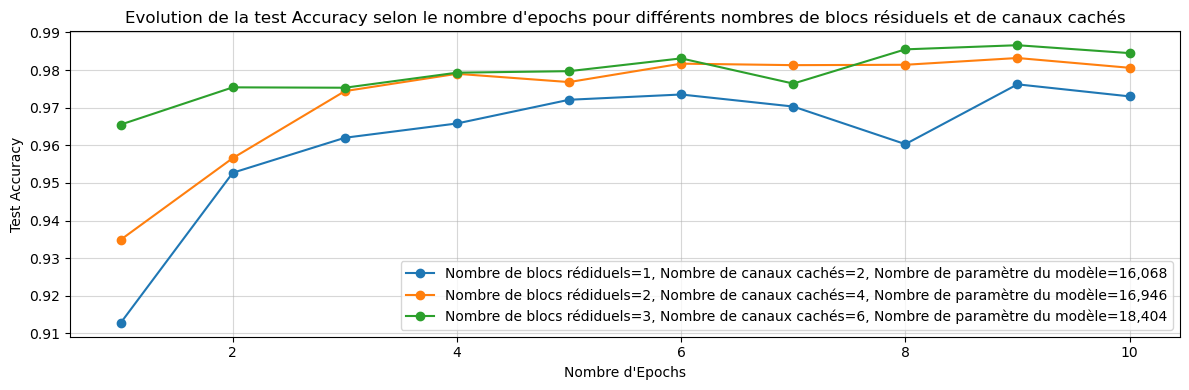

In [32]:
import matplotlib.pyplot as plt

# Affichage des résultats
plt.figure(figsize=(12, 4))
for (l, h), accs in results.items():
    label = f"Nombre de blocs rédiduels={l}, Nombre de canaux cachés={h}, Nombre de paramètre du modèle={params_dict[(l, h)]:,}"
    plt.plot(
        range(1, NUM_EPOCH + 1),
        accs,
        marker='o',
        label=label
    )

plt.xlabel("Nombre d'Epochs")
plt.ylabel("Test Accuracy")
plt.title("Evolution de la test Accuracy selon le nombre d'epochs pour différents nombres de blocs résiduels et de canaux cachés")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


In [33]:
total_params_MLP = sum(p.numel() for p in model_MLP.parameters() if p.requires_grad)
total_params_ConvModel = sum(p.numel() for p in model_CNN.parameters() if p.requires_grad)
total_params_DeepConv = sum(p.numel() for p in Deep_CNN.parameters() if p.requires_grad)
print(f"Nombre de paramètres du MLP: {total_params_MLP:,}")
print(f"Nombre de paramètres du ConvModel: {total_params_ConvModel:,}")
print(f"Nombre de paramètres du DeepConv: {total_params_DeepConv:,}")

Nombre de paramètres du MLP: 16,110
Nombre de paramètres du ConvModel: 13,610
Nombre de paramètres du DeepConv: 146,490


In [36]:
ResNet = ResidualModel(nb_ResBlock=2, hidden_channels=4).to(device)
print("Architecture du modèle ResNet avec 2 bloc résiduels de 4 canaux cachés :\n", ResNet)

Architecture du modèle ResNet avec 2 bloc résiduels de 4 canaux cachés :
 ResidualModel(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU(inplace=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (resblocks): Sequential(
    (0): ResidualBlockConv(
      (conv1): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
    (1): ResidualBlockConv(
      (conv1): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


___

**```REPONSES```**

* Can you match the accuracy of the two-layer network ?
> Oui avec un seul Resblock consitué seulement de 2 canaux cachés, mon modèle atteint déjà un test accuracy de 97% similaire au niveau atteint par le modèle avec 2 couches de convolution (Conv2d)

* Can you exceed it ? What happens when you increase the number of layers ? 
> Oui les meilleurs modèles (avec 3 ResBlock avec 6 canaux cachés chacun) atteignent une ```accuracy test > 98%``` VS une test accuracy à 97\% pour le 2-layer network

> Comme le montre le graphique, plus le nombre de blocs résiduels est elevé pour le test accuracy au bout des 10 epoch est élévé, cependant on comence à atteindre un pallier au dela de 2 blocs résiduels (la test accuracy dépasse difficilement 98\%)

* Look at the details of the ResNet architecture on the lecture's slides to get an idea of how to increase the number of hidden neurons and the number of layers. One of the strengths of ResNets was there relatively low number of parameters compared to a multi-layer architecture like that of the previous section, does this show in your experiments ?
> On remarque que notre modèle avec 2 blocs résiduels composés 4 canaux cachés comporte ```7 couches```, soit un grand nombre de couches, mais totalise moins de ```17 000 paramètres```. 

> En comparaison, les modèles précédents ```3-Layers MLP``` et le modèle ```2-layers ConvNet``` ont avec  **3 couches** uniquement un nombre de **paramètres très similaires** (16 110 et 13 610) . 

> Encore plus frappant, le modèle DeepConv avec ses **5 couches** totalise **146 500 paramètres**, soit 9 fois plus que notre modèle Resnet. Pourtant notre modèle avec moins de paramètre est le seul des 4 à obtenir un score ```accuracy_test``` supérieur à **98\%**

___

# Part C - Reimplementing loss functions

## C.0 - Combining losses
First, we recall that, for a batch of score vectors $s\in\mathbb{R}^{n\times C}$ and true labels $y\in[1,C]^n$, **cross entropy** is defined as

$$
CE(s, y) = -\frac{1}{n} \sum_{i=1}^n \log\!\bigl(\mathrm{softmax}(s_i)_{y_i}\bigr)
$$

where 
$\mathrm{softmax}(x)_i= \frac{e^{x_i}}{\displaystyle\sum_{j=1}^{C} e^{x_j}},$ is the probability associated to class $i\in[1,C]$ for a score vector $x\in\mathbb{R}^C$.

Let's try to compute cross-entropy in three different ways (see the [documentation](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)):
1. Using `nn.CrossEntropyLoss()`.
2. Using `nn.NLLLoss()` and `nn.LogSoftmax()`.
3. Using `nn.NLLLoss()` and `nn.Softmax()`.

Check that the output is the same for all three methods on Gaussian random scores `torch.randn(n_batch, n_classes)` and random labels `torch.randint(0, n_classes, [n_batch])`, where `n_batch=4` and `n_classes=10`. Note that the scores are real valued vectors while the labels are integers corresponding to the true class.

In [37]:
n_batch = 4
n_classes = 10

torch.manual_seed(0)
scores = torch.randn(n_batch, n_classes)
labels = torch.randint(0, n_classes, (n_batch,))

# Méthode 1) nn.CrossEntropyLoss
CE = nn.CrossEntropyLoss()
loss1 = CE(scores, labels)

# Méthode 2) NLLLoss + LogSoftmax
NLLL =  nn.NLLLoss()
logsoft = nn.LogSoftmax(dim=1)
loss2 = NLLL(logsoft(scores), labels)

# 3) Softmax + log + NLLLoss
soft    = nn.Softmax(dim=1)
probs   = soft(scores)           
logprobs= torch.log(probs)       # en convertit en log-probabilités
loss3   = NLLL(logprobs, labels) # exactement comme LogSoftmax+NLLLoss


print(f"loss1 (CrossEntropy):               {loss1.item():.6f}")
print(f"loss2 (LogSoftmax + NLLLoss):       {loss2.item():.6f}")
print(f"loss3 (Softmax + log + NLLLoss):    {loss3.item():.6f}")

# check equality
print("\nloss1 == loss2 -->", torch.allclose(loss1, loss2))
print("loss1 == loss3 -->", torch.allclose(loss1, loss3))
print("loss2 == loss3 -->", torch.allclose(loss2, loss3))



loss1 (CrossEntropy):               2.997688
loss2 (LogSoftmax + NLLLoss):       2.997688
loss3 (Softmax + log + NLLLoss):    2.997688

loss1 == loss2 --> True
loss1 == loss3 --> True
loss2 == loss3 --> True


---
> Les 3 méthodes donnent bien la **meme valeur** pour la loss !

## C.1 - Re-implementation
Now re-implement cross-entropy using base functions (`torch.log`, `torch.exp`, `torch.sum`, etc...). Verify that your function returns the same value as Pytorch's implementation.

In [38]:
def manual_cross_entropy(scores, labels):
    # Calcul des probabilités softmax
    exp_scores = torch.exp(scores)                            # (N, C)
    sum_exp    = exp_scores.sum(dim=1, keepdim=True)          # (N, 1)
    probs      = exp_scores / sum_exp                         # (N, C)

    # 2) on récupère les log-probabilités
    log_probs = torch.log(probs)                              

    # 3) on récupère la log-probabilités de la vraie classe pour chaque batch
    N = scores.size(0) # nombre de batch
    true_log = log_probs[torch.arange(N), labels]      
    cross_entropy = -true_log.mean() # 
    #print(N)
    #print(true_log)

    return cross_entropy

In [40]:
n_batch = 4
n_classes = 10

torch.manual_seed(0)
scores = torch.randn(n_batch, n_classes)
labels = torch.randint(0, n_classes, (n_batch,))

# builtin loss
loss_pytorch = CE(scores, labels)

# manual loss
loss_manual = manual_cross_entropy(scores, labels)

print(f"Pytorch:  {loss_pytorch.item():.6f}")
print(f"Manuelle: {loss_manual.item():.6f}")
print("Loss pytorch == Loss manual ? --> ", torch.allclose(loss_pytorch, loss_manual))

Pytorch:  2.997688
Manuelle: 2.997688
Loss pytorch == Loss manual ? -->  True


## C.2 - Stability analysis
Softmax probabilities can be relatively unstable due to their use of exponentials. Pytorch implementations thus usually use log probas or logits to avoid overflows or floating point errors. Test all methods (including your own) on Gaussian random scores of standard deviation equal to $100$. Which methods are stable? Why? Is it an issue in practice?

In [41]:
torch.manual_seed(0)
n_batch, n_classes = 4, 10
scores = torch.normal(0, 100, (n_batch, n_classes))  
labels = torch.randint(0, n_classes, (n_batch,))

# Méthode 1) nn.CrossEntropyLoss
CE = nn.CrossEntropyLoss()
loss1 = CE(scores, labels)

# Méthode 2) NLLLoss + LogSoftmax
NLLL =  nn.NLLLoss()
logsoft = nn.LogSoftmax(dim=1)
loss2 = NLLL(logsoft(scores), labels)

# 3) Softmax + log + NLLLoss
soft    = nn.Softmax(dim=1)
probs   = soft(scores)           
logprobs= torch.log(probs)       # en convertit en log-probabilités
loss3   = NLLL(logprobs, labels) # exactement comme LogSoftmax+NLLLoss

# 4) Manual cross-entropy
loss_manual = manual_cross_entropy(scores, labels)

print("Méthode 1 - CrossEntropyLoss:      ", loss1)
print("Méthode 2 - LogSoftmax + NLLLoss:  ", loss2)
print("Méthode 3 - Softmax  + NLLLoss:    ", loss3)
print("Méthode manuelle :                 ", loss_manual)

Méthode 1 - CrossEntropyLoss:       tensor(179.4133)
Méthode 2 - LogSoftmax + NLLLoss:   tensor(179.4133)
Méthode 3 - Softmax  + NLLLoss:     tensor(inf)
Méthode manuelle :                  tensor(inf)


In [42]:
torch.exp(torch.tensor([100.0]))

tensor([inf])

---
> On remarque que les 2 premières méthodes (`nn.CrossEntropyLoss()` et celle utilisant `nn.NLLLoss()` + `nn.LogSoftmax()`) sont stables alors que méthode 3 et la méthode manuelle qui calcule la probabilité avec la fonction **softmax** avant de passer au log donnent ici une valeur infini et ne sont donc **pas stables**.

> Cela s'explique par le fait que des valeurs grande de la matrice score (typiquement >100) deviennent trop grande pour etre stocké sous forme de float une fois passé à l'exponentionel avec `torch.exp()` 

> **torch.exp(torch.tensor([100.0])) = tensor([inf])** comme le montre l'exemple ci-dessus
---

Re-implement a stable version of cross-entropy.

In [43]:
def stable_manual_cross_entropy(scores, labels):

    
    max_scores = scores.max(dim=1, keepdim=True)[0]  # shape (N, 1)
    print("Valeur max de la matrice scores:    ", round(max_scores.max().item(), 4))

    # 1) On soustrait la valeur max de chaque ligne pour la stabilité numérique (c'est comme si on divisait au numérateur et au dénominateur de la formule softmax par la même valeur qui est max du scores)
    scores_shift = scores - max_scores               # shape (N, C)

    # 2) Calcul du log‐sum‐exp
    exp_shift       = torch.exp(scores_shift)             # (N, C)
    sum_exp         = exp_shift.sum(dim=1, keepdim=True)  # (N, 1)
    log_sum_exp     = torch.log(sum_exp)                  # (N, 1)
    log_probs       = scores_shift - log_sum_exp          # (N, C) 

    # 3) Extraction des scores « vrais » pour chaque exemple
    N = scores.size(0) # nombre de batch
    true_log = log_probs[torch.arange(N), labels]      
    cross_entropy = - true_log.mean() 

    return cross_entropy


In [44]:
# --- quick sanity check on large logits ---
torch.manual_seed(0)
n_batch, n_classes = 4, 10
scores = torch.normal(0, 100, (n_batch, n_classes))  
labels = torch.randint(0, n_classes, (n_batch,))

loss_pytorch = CE(scores, labels)
loss_manuelle_stable = stable_manual_cross_entropy(scores, labels)

print("Pytorch Cross Entorpy loss:         ", loss_pytorch.item())  # should be a finite number
print("Manual Cross Entorpy loss (Stable): ", loss_manuelle_stable.item())  # should be a finite number
print("Ecart entre les deux méthodes:      ", abs(loss_pytorch - loss_manuelle_stable).item()) # should be small

Valeur max de la matrice scores:     185.3006
Pytorch Cross Entorpy loss:          179.41334533691406
Manual Cross Entorpy loss (Stable):  179.413330078125
Ecart entre les deux méthodes:       1.52587890625e-05


---
> On constate bien que même avec grandes valeurs (typiquement un max de la matrice score > 100), notre implémentation reste stable et donne une valeur pour la loss proche à $10^{-5}$ de la valeur calculée avec la fonction `nn.CrossEntropyLoss()` de Pytorch